In [1]:
library(limma)

In [ ]:
# Definir las rutas 
path_controles <- "C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawControles"
path_hormonas  <- "C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawHormonas"

In [3]:
# 3. Listar los archivos .txt.gz que hay dentro de cada carpeta
# full.names = TRUE es CLAVE: nos da la dirección exacta de cada archivo
files_controles <- list.files(path = path_controles, 
                              pattern = "^GSM.*\\.txt\\.gz$", 
                              full.names = TRUE)

files_hormonas  <- list.files(path = path_hormonas, 
                              pattern = "^GSM.*\\.txt\\.gz$", 
                              full.names = TRUE)

In [ ]:
# Combinar ambas listas de archivos
all_files <- c(files_controles, files_hormonas)
print(paste("Archivos encontrados:", length(all_files)))

[1] "Archivos encontrados: 22"


# Lectura con limma

In [6]:
# Leemos los archivos. 
# source="agilent" le dice a R qué columnas buscar.
# green.only=TRUE es porque casi seguro son de un solo color (Cy3).
raw_data <- read.maimages(all_files, source="agilent", green.only=TRUE)

# Fijate que haya cargado bien
print(dim(raw_data))

Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawControles/GSM758904.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawControles/GSM758942.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawControles/GSM758957.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawControles/GSM758965.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawControles/GSM758969.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawHormonas/GSM758902.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawHormonas/GSM758905.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawHormonas/GSM758906.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawHormonas/GSM758909.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawHormonas/GSM758911.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawHormonas/GSM758912.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawHormonas/GSM758922.txt 
Read C:/Users/Fran/Documents/Doctor

## Etiquetar muestras

In [7]:
# 1. Definimos los IDs de cada grupo (según tu lista definitiva)
ids_control <- c("GSM758904", "GSM758942", "GSM758957", "GSM758965", "GSM758969")
ids_estrog  <- c("GSM758905", "GSM758911", "GSM758925", "GSM758958", "GSM758966", "GSM758970")
ids_proges  <- c("GSM758906", "GSM758912", "GSM758926", "GSM758959", "GSM758967", "GSM758971")
ids_combo   <- c("GSM758902", "GSM758909", "GSM758922", "GSM758962", "GSM758974")

# 2. Función para detectar el grupo según el nombre del archivo
asignar_grupo <- function(ruta_completa) {
  archivo <- basename(ruta_completa)       # Se queda solo con el nombre "GSM...txt"
  nombre_limpio <- sub("\\.txt$", "", archivo) # Le saca el .txt
  
  if (nombre_limpio %in% ids_control) return("Control")
  if (nombre_limpio %in% ids_estrog)  return("Estrogeno")
  if (nombre_limpio %in% ids_proges)  return("Progesterona")
  if (nombre_limpio %in% ids_combo)   return("Combo")
  return("Desconocido")
}

# 3. Creamos la tabla de targets y la metemos dentro del objeto raw_data
mis_grupos <- sapply(all_files, asignar_grupo)
raw_data$targets <- data.frame(FileName = basename(all_files), Group = mis_grupos)

# Chequeo rápido: ¿Están bien contados?
table(raw_data$targets$Group)


       Combo      Control    Estrogeno Progesterona 
           5            5            6            6 

## Normalizacion para un color

In [8]:
# Paso 3: Normalización para Single-Channel (Agilent)

# A. Corrección de fondo (Background Correction)
# offset=16 o 50 ayuda a evitar logaritmos de cero más adelante.
data_bkg <- backgroundCorrect(raw_data, method="normexp", offset=50)

# B. Normalización entre arrays (Quantile)
# Esto alinea las distribuciones de todas tus muestras
data_norm <- normalizeBetweenArrays(data_bkg, method="quantile")

# Chequeo:
# Si mirás las dimensiones, deben ser las mismas (aprox 40k genes x 22 muestras)
dim(data_norm)

Array 1 corrected
Array 2 corrected
Array 3 corrected
Array 4 corrected
Array 5 corrected
Array 6 corrected
Array 7 corrected
Array 8 corrected
Array 9 corrected
Array 10 corrected
Array 11 corrected
Array 12 corrected
Array 13 corrected
Array 14 corrected
Array 15 corrected
Array 16 corrected
Array 17 corrected
Array 18 corrected
Array 19 corrected
Array 20 corrected
Array 21 corrected
Array 22 corrected


[1] 15744    22

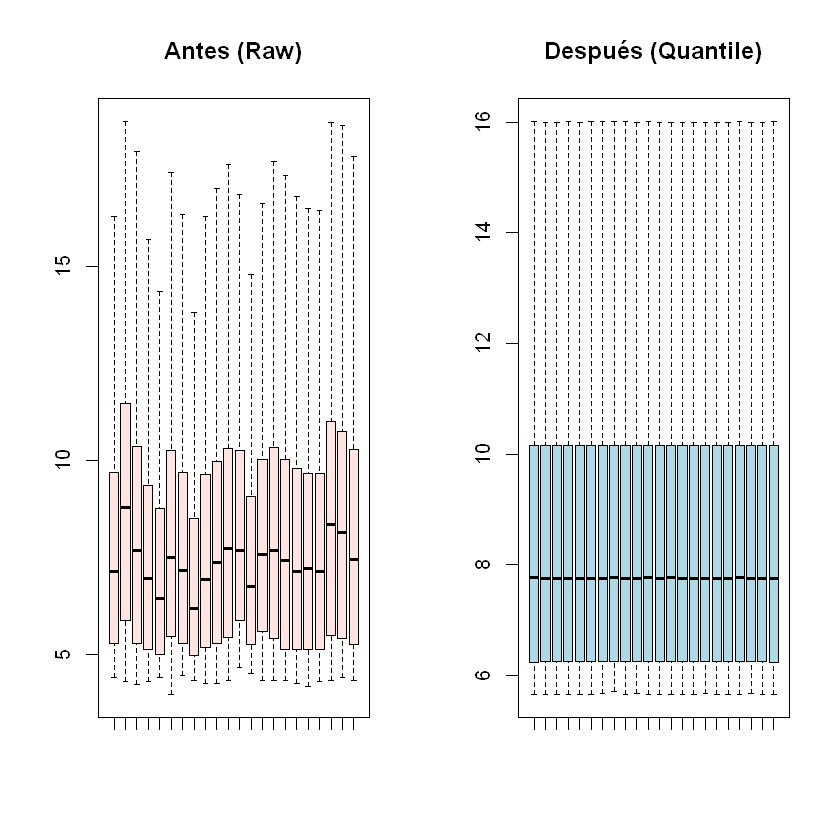

In [9]:
# Comparación visual
par(mfrow=c(1,2)) # Dividir pantalla en 2

# 1. Antes (Usa raw_data$E porque es single channel)
# log2 transforma los datos para que se vean mejor en el gráfico
boxplot(log2(raw_data$E), main="Antes (Raw)", names=FALSE, col="mistyrose", outline=FALSE)

# 2. Después (data_norm ya viene en escala logarítmica usualmente tras normalizeBetweenArrays si son 1-color, 
# pero por las dudas chequeamos sus valores. Para Agilent suele devolver log-expression values).
boxplot(data_norm$E, main="Después (Quantile)", names=FALSE, col="lightblue", outline=FALSE)

## Limpiar datos innecesarios

In [10]:
# Verificamos qué tipo de sondas hay (0 son genes, 1/-1 son controles técnicos)
table(data_norm$genes$ControlType)

# Nos quedamos SOLO con las que son genes (ControlType == 0)
# La función subset de limma sirve para filtrar filas manteniendo la estructura
data_clean <- data_norm[data_norm$genes$ControlType == 0, ]

# Chequeamos cuántos genes nos quedaron (deberían ser unos 30.000 - 40.000 aprox)
dim(data_clean)


   -1     0     1 
   77 15208   459 

[1] 15208    22

## Definir donantes

In [11]:
# Función rápida para asignar Donante según el número de GSM
asignar_donante <- function(nombre_archivo) {
  # Extraemos el numero del nombre del archivo
  id <- sub("GSM", "", sub("\\.txt", "", basename(nombre_archivo)))
  
  # Mapeo según la investigación que hicimos antes:
  # M#20: 65(C), 66(E), 67(P), 02(Combo)
  if(id %in% c("758965","758966","758967","758902")) return("Donante20")
  
  # M#21: 69(C), 70(E), 71(P), 74(Combo)
  if(id %in% c("758969","758970","758971","758974")) return("Donante21")
  
  # M#25: 04(C), 05(E), 06(P), 09(Combo)
  if(id %in% c("758904","758905","758906","758909")) return("Donante25")
  
  # M#24: 42(C), 25(E), 26(P), 22(Combo - OJO este combo era del 23 pero verifiquemos)
  # Nota: El 22 era del M23, así que si tenes el archivo 22, quedará como "Otros"
  if(id %in% c("758942","758925","758926")) return("Donante24")
  
  # M#27: 57(C), 58(E), 59(P), 62(Combo)
  if(id %in% c("758957","758958","758959","758962")) return("Donante27")
  
  return("Otros") # Para los huerfanos del M23 si los cargaste
}

# Creamos la columna Donante en los targets
data_clean$targets$Donante <- sapply(data_clean$targets$FileName, asignar_donante)

# Miramos la tabla cruzada para ver que cada donante tenga sus tratamientos
table(data_clean$targets$Donante, data_clean$targets$Group)

           
            Combo Control Estrogeno Progesterona
  Donante20     1       1         1            1
  Donante21     1       1         1            1
  Donante24     0       1         1            1
  Donante25     1       1         1            1
  Donante27     1       1         1            1
  Otros         1       0         1            1

## Defino matriz de comparacion

In [12]:
# Definimos los factores
Grupo   <- factor(data_clean$targets$Group)
Donante <- factor(data_clean$targets$Donante)

# Creamos la matriz de diseño
# "~ 0 + Grupo + Donante" significa:
# "Explicame la expresión génica basándote en el Tratamiento, pero ajustando por el Donante"
design <- model.matrix(~ 0 + Grupo + Donante)

# Limpiamos los nombres de las columnas para que sea fácil leerlos después
colnames(design) <- gsub("Grupo", "", colnames(design))

# Revisamos cómo quedó la matriz (solo las primeras filas)
head(design)

,Combo,Control,Estrogeno,Progesterona,DonanteDonante21,DonanteDonante24,DonanteDonante25,DonanteDonante27,DonanteOtros
1,0,1,0,0,0,0,1,0,0
2,0,1,0,0,0,1,0,0,0
3,0,1,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0
5,0,1,0,0,1,0,0,0,0
6,1,0,0,0,0,0,0,0,0


## Saco los que no sean donantes pareados

In [13]:
# 1. Filtramos: Nos quedamos solo con los que NO son "Otros"
keep <- data_clean$targets$Donante != "Otros"
data_final <- data_clean[, keep]

# 2. Re-factorizamos para borrar los niveles vacíos (fantasmas)
data_final$targets$Group   <- factor(data_final$targets$Group)
data_final$targets$Donante <- factor(data_final$targets$Donante)

# 3. Ponemos al "Control" como la REFERENCIA (el nivel basal)
# Esto es clave: le dice a R que todo se compara CONTRA el Control.
data_final$targets$Group <- relevel(data_final$targets$Group, ref="Control")

# Chequeo final (Ahora "Otros" debería haber desaparecido)
table(data_final$targets$Donante, data_final$targets$Group)

           
            Control Combo Estrogeno Progesterona
  Donante20       1     1         1            1
  Donante21       1     1         1            1
  Donante24       1     0         1            1
  Donante25       1     1         1            1
  Donante27       1     1         1            1

## Modelo para expresion diferencial

In [14]:
# A. Crear la Matriz de Diseño (Sin "Otros" y con Control de referencia)
# Al tener intercept (sin el "0 +"), R calcula los cambios relativos al Control automáticamente.
design <- model.matrix(~ Donante + Group, data = data_final$targets)

# Mirá las columnas ahora. Deberías ver:
# "(Intercept)", "Donante21"..., "GroupEstrogeno", "GroupProgesterona", etc.
colnames(design)

# B. Ajustar el modelo lineal (Fit)
fit <- lmFit(data_final, design)

# C. Calcular la estadística Bayesiana (eBayes)
# Esto "suaviza" la varianza y hace que el test sea robusto con pocas muestras.
fit <- eBayes(fit)

[1] "(Intercept)"       "DonanteDonante21"  "DonanteDonante24" 
[4] "DonanteDonante25"  "DonanteDonante27"  "GroupCombo"       
[7] "GroupEstrogeno"    "GroupProgesterona"

# Estrogeno

In [19]:
# Pedimos los top genes para el coeficiente de Estrógeno
# coef= "GroupEstrogeno" busca la columna que compara E vs Control.
res_estrogeno <- topTable(fit, coef="GroupEstrogeno", number=Inf, sort.by="P")

# Miramos los 10 genes más significativos
head(res_estrogeno)

# ¿Cuántos genes se prendieron o apagaron significativamente (FDR < 0.05)?
# adj.P.Val < 0.05 es el estándar científico.
table(res_estrogeno$adj.P.Val < 0.05)

,Row,Col,ControlType,ProbeName,SystematicName,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
146,2,64,0,A_24_P941339,NM_000219,0.5096334,7.163346,4.132227,0.001270021,0.9999772,-2.723323
10969,134,63,0,A_33_P3745146,NM_001098517,0.5025667,6.393059,3.066361,0.009348809,0.9999772,-3.359935
2892,36,22,0,A_23_P69179,NM_018192,-0.3804825,8.002815,-2.932103,0.012055346,0.9999772,-3.448706
5256,65,8,0,A_23_P146654,NM_004323,0.2328959,12.202173,2.892483,0.012993720,0.9999772,-3.475178
1102,14,36,0,A_24_P112447,NM_020354,0.1773069,6.534162,2.885204,0.013173841,0.9999772,-3.480054
11966,146,76,0,A_23_P146654,NM_004323,0.2465501,12.192879,2.869983,0.013558462,0.9999772,-3.490262



FALSE 
15208 

In [27]:
# Miremos cuántos pasan el P-valor crudo (sin corrección de error múltiple)
# Esto es para "chusmear", no es estadísticamente robusto, pero sirve para explorar.
table(res_estrogeno$P.Value < 0.05)


FALSE  TRUE 
15133    75 

# Progesterona

In [25]:
res_progesterona <- topTable(fit, coef="GroupProgesterona", number=Inf, sort.by="P")

# Miramos los top 10
head(res_progesterona)

# Conteo de significativos
table(res_progesterona$adj.P.Val < 0.05)

,Row,Col,ControlType,ProbeName,SystematicName,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
589,8,15,0,A_23_P342067,NM_175866,0.3220063,10.028517,4.070638,0.001421974,0.9999606,-2.756372
13188,161,68,0,A_33_P3268284,NM_001494,0.3750329,9.819650,4.015713,0.001573270,0.9999606,-2.786249
7860,96,70,0,A_32_P22338,NM_013374,0.3610671,8.634699,3.957738,0.001751021,0.9999606,-2.818198
9119,112,17,0,A_23_P26024,NM_032413,-0.7485780,10.912389,-3.863600,0.002084815,0.9999606,-2.870975
6979,86,9,0,A_24_P109554,NM_007018,0.3822398,8.106301,3.788338,0.002398232,0.9999606,-2.913965
12203,149,67,0,A_23_P359738,NM_015630,0.3250654,9.479742,3.737845,0.002635177,0.9999606,-2.943200



FALSE 
15208 

# Volcanos

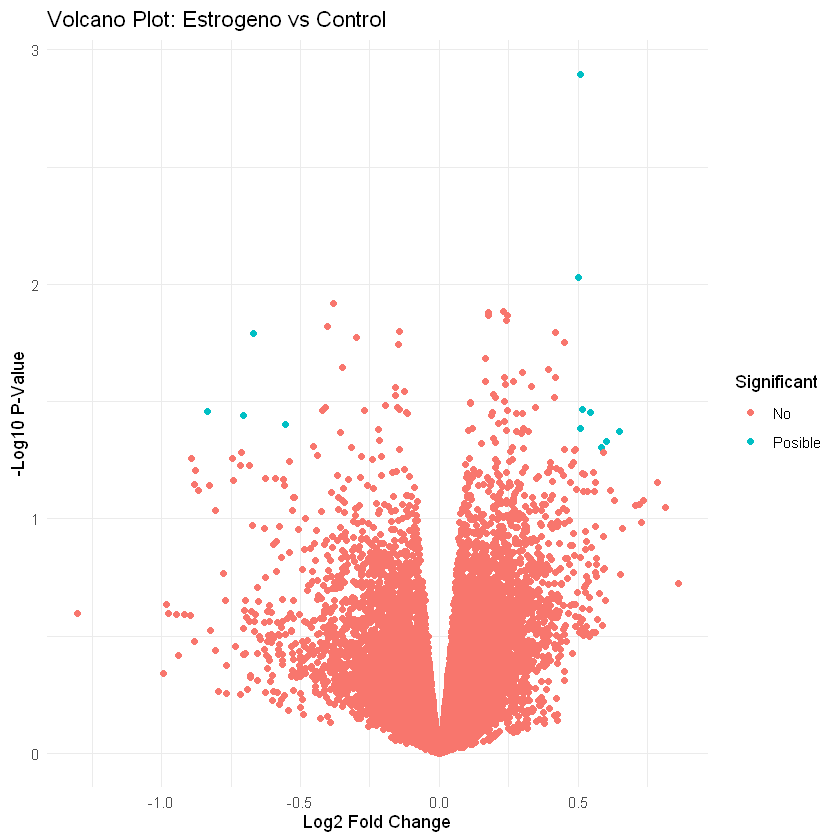

In [26]:
# Cargar librería gráfica (si no la tenés, usa plot básico)
library(ggplot2) # Ojalá la tengas, sino avisame y hacemos el básico

# Usamos la tabla completa de Estrogeno
volcano_data <- res_estrogeno

# Agregamos una columna para pintar de color lo que sea "medio interesante"
# Criterio laxo: P-valor crudo < 0.05 y LogFC > 0.5
volcano_data$Significant <- ifelse(volcano_data$P.Value < 0.05 & abs(volcano_data$logFC) > 0.5, "Posible", "No")

# Graficamos
ggplot(volcano_data, aes(x=logFC, y=-log10(P.Value))) +
  geom_point(aes(col=Significant)) +
  theme_minimal() +
  ggtitle("Volcano Plot: Estrogeno vs Control") +
  xlab("Log2 Fold Change") +
  ylab("-Log10 P-Value")